In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
ds = load_dataset("dair-ai/emotion")

label_names = ds['train'].features['label'].names
print("Emotion classes:", label_names)

df_train = pd.DataFrame({
    'text': ds['train']['text'],
    'label': [label_names[i] for i in ds['train']['label']]
})

df_val = pd.DataFrame({
    'text': ds['validation']['text'],
    'label': [label_names[i] for i in ds['validation']['label']]
})

df_test = pd.DataFrame({
    'text': ds['test']['text'],
    'label': [label_names[i] for i in ds['test']['label']]
})

print("Train size:", len(df_train))
print("Validation size:", len(df_val))
print("Test size:", len(df_test))

df_train.head()

Emotion classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Train size: 16000
Validation size: 2000
Test size: 2000


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


text           0
label          0
text_length    0
dtype: int64


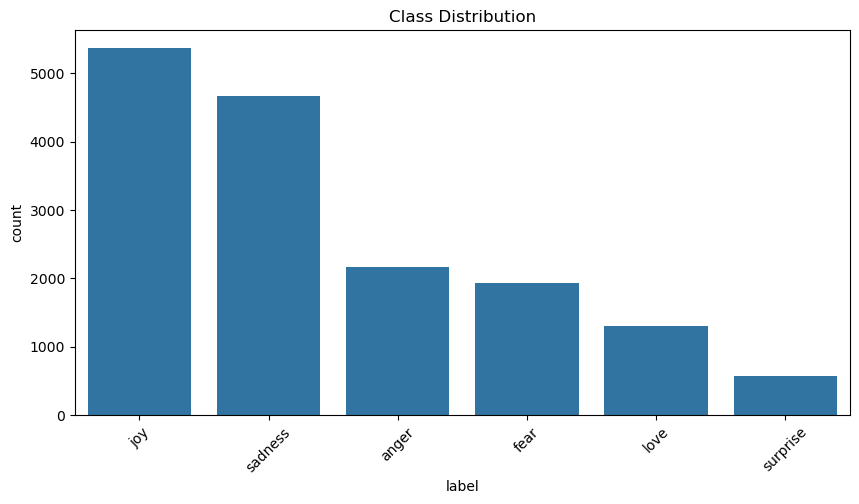

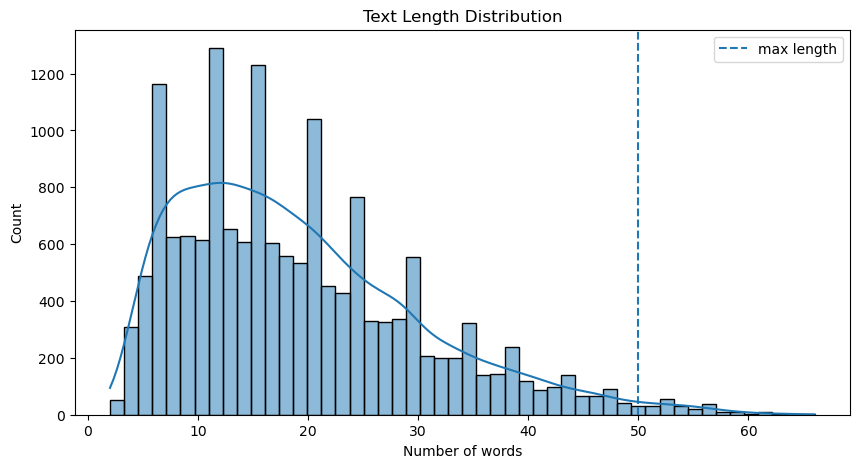

In [12]:
print(df_train.isnull().sum())

plt.figure(figsize=(10, 5))
sns.countplot( x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

df_train['text_length'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train['text_length'], bins=50, kde=True)
plt.axvline(50, linestyle='--', label='max length')
plt.xlabel("Number of words")
plt.title("Text Length Distribution")
plt.legend()
plt.show()

In [7]:
train_texts = list(ds['train']['text'])
val_texts = list(ds['validation']['text'])
test_texts = list(ds['test']['text'])

train_labels = list(ds['train']['label'])
val_labels = list(ds['validation']['label'])
test_labels = list(ds['test']['label'])

print(f"Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

Train: 16000, Val: 2000, Test: 2000


In [8]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
vocab_size = tokenizer.vocab_size
pad_token_id = tokenizer.pad_token_id

MAX_LEN = 50
BATCH_SIZE = 32

def tokenize_texts(texts):
    return tokenizer(texts, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

train_enc = tokenize_texts(train_texts)
val_enc = tokenize_texts(val_texts)
test_enc = tokenize_texts(test_texts)

print("Train input_ids shape:", train_enc['input_ids'].shape)

Train input_ids shape: torch.Size([16000, 50])


In [14]:
class EmotionDataset(Dataset):
    def __init__(self, encodings, labels):
        self.input_ids = encodings['input_ids']
        self.attention_mask = encodings['attention_mask']
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }

train_dataset = EmotionDataset(train_enc, train_labels)
val_dataset = EmotionDataset(val_enc, val_labels)
test_dataset = EmotionDataset(test_enc, test_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights_tensor)

Class weights: tensor([0.5715, 0.4973, 2.0450, 1.2351, 1.3767, 4.6620], device='cuda:0')


In [15]:
# LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        x = hidden[-1]
        x = self.dropout(x)
        return self.fc(x)

# GRU Model
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        x = hidden[-1]
        x = self.dropout(x)
        return self.fc(x)

In [16]:
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    best_model_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

Epoch 1/20 - Train Loss: 1.6262 - Val Loss: 1.1759
Epoch 2/20 - Train Loss: 0.8142 - Val Loss: 0.5584
Epoch 3/20 - Train Loss: 0.3844 - Val Loss: 0.3813
Epoch 4/20 - Train Loss: 0.2371 - Val Loss: 0.3627
Epoch 5/20 - Train Loss: 0.1640 - Val Loss: 0.4256
Epoch 6/20 - Train Loss: 0.1129 - Val Loss: 0.4104
Epoch 7/20 - Train Loss: 0.0882 - Val Loss: 0.4361
Early stopping at epoch 7


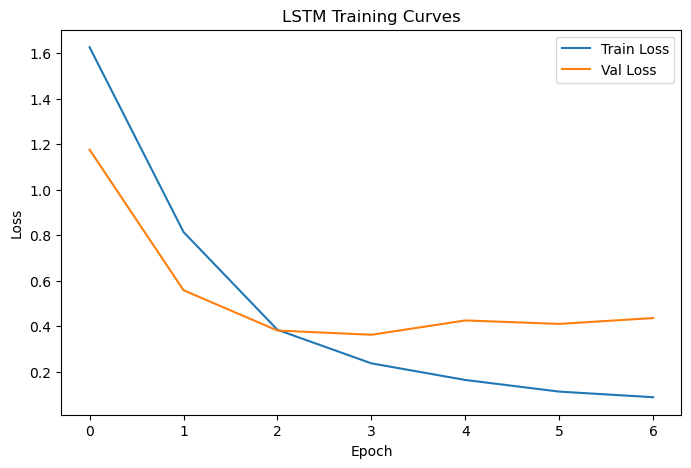

In [17]:
lstm_model = LSTMClassifier(
    vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=6, pad_idx=pad_token_id, dropout=0.3)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)


lstm_model, lstm_train_loss, lstm_val_loss = train_model(
    lstm_model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3)

plt.figure(figsize=(8,5))
plt.plot(lstm_train_loss, label='Train Loss')
plt.plot(lstm_val_loss, label='Val Loss')
plt.legend()
plt.title('LSTM Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Epoch 1/20 - Train Loss: 1.6406 - Val Loss: 1.1350
Epoch 2/20 - Train Loss: 0.6475 - Val Loss: 0.4146
Epoch 3/20 - Train Loss: 0.2607 - Val Loss: 0.2874
Epoch 4/20 - Train Loss: 0.1613 - Val Loss: 0.2964
Epoch 5/20 - Train Loss: 0.1049 - Val Loss: 0.3540
Epoch 6/20 - Train Loss: 0.0704 - Val Loss: 0.3900
Early stopping at epoch 6


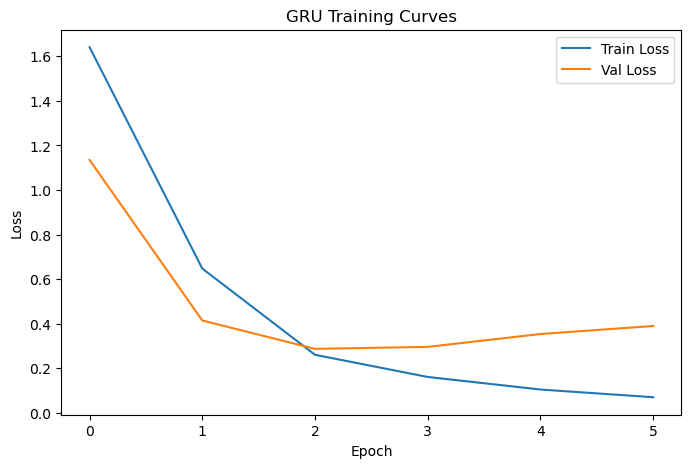

In [18]:
gru_model = GRUClassifier(
    vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=6, pad_idx=pad_token_id, dropout=0.3
)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)

gru_model, gru_train_loss, gru_val_loss = train_model(
    gru_model, train_loader, val_loader, criterion, optimizer, epochs=20, patience=3)

plt.figure(figsize=(8,5))
plt.plot(gru_train_loss, label='Train Loss')
plt.plot(gru_val_loss, label='Val Loss')
plt.legend()
plt.title('GRU Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 - Train Loss: 0.6960 - Val Loss: 0.2227
Epoch 2/5 - Train Loss: 0.2010 - Val Loss: 0.1639
Epoch 3/5 - Train Loss: 0.1531 - Val Loss: 0.1930
Epoch 4/5 - Train Loss: 0.1209 - Val Loss: 0.1812
Early stopping at epoch 4


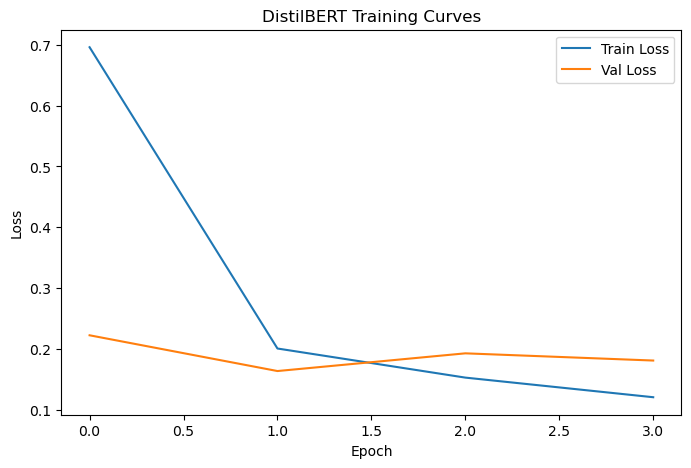

In [19]:
import copy

distilbert_model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6).to(device)

optimizer = AdamW(distilbert_model.parameters(), lr=2e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

def train_distilbert(model, train_loader, val_loader, criterion, optimizer, epochs=5, patience=2):
    model.to(device)
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    best_model_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses

distilbert_model, db_train_loss, db_val_loss = train_distilbert(distilbert_model, train_loader, val_loader, criterion, optimizer, epochs=5, patience=2)

plt.figure(figsize=(8,5))
plt.plot(db_train_loss, label='Train Loss')
plt.plot(db_val_loss, label='Val Loss')
plt.legend()
plt.title('DistilBERT Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

LSTM Test Accuracy: 0.8560
              precision    recall  f1-score   support

     sadness       0.96      0.85      0.90       581
         joy       0.93      0.84      0.88       695
        love       0.67      0.87      0.76       159
       anger       0.82      0.89      0.85       275
        fear       0.70      0.92      0.80       224
    surprise       0.75      0.74      0.75        66

    accuracy                           0.86      2000
   macro avg       0.81      0.85      0.82      2000
weighted avg       0.87      0.86      0.86      2000



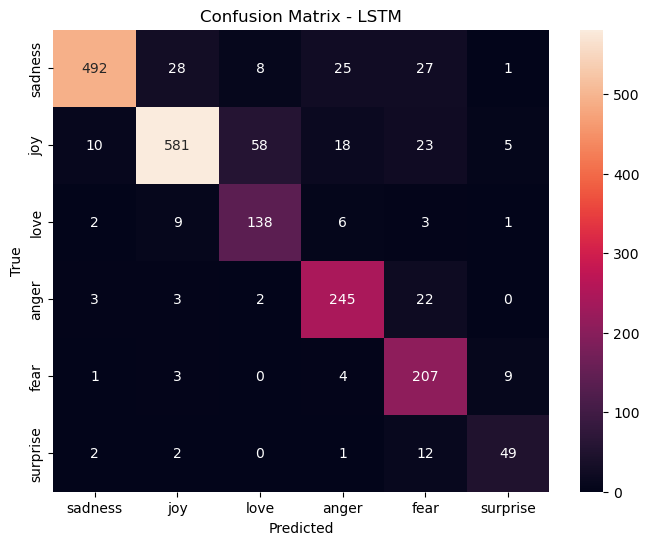

GRU Test Accuracy: 0.8965
              precision    recall  f1-score   support

     sadness       0.96      0.92      0.94       581
         joy       0.94      0.87      0.90       695
        love       0.71      0.92      0.80       159
       anger       0.85      0.93      0.89       275
        fear       0.90      0.87      0.88       224
    surprise       0.69      0.85      0.76        66

    accuracy                           0.90      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.90      0.90      0.90      2000



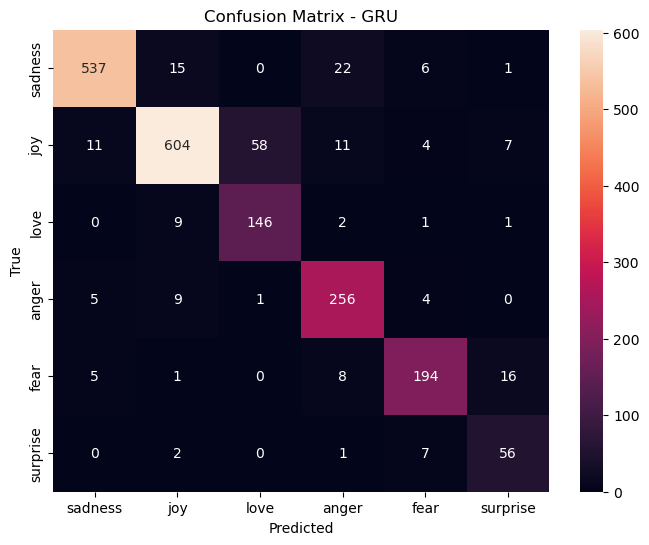

DistilBERT Test Accuracy: 0.9240
              precision    recall  f1-score   support

     sadness       0.98      0.94      0.96       581
         joy       0.98      0.91      0.94       695
        love       0.74      0.98      0.84       159
       anger       0.91      0.94      0.93       275
        fear       0.88      0.91      0.90       224
    surprise       0.72      0.82      0.77        66

    accuracy                           0.92      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.93      0.92      0.93      2000



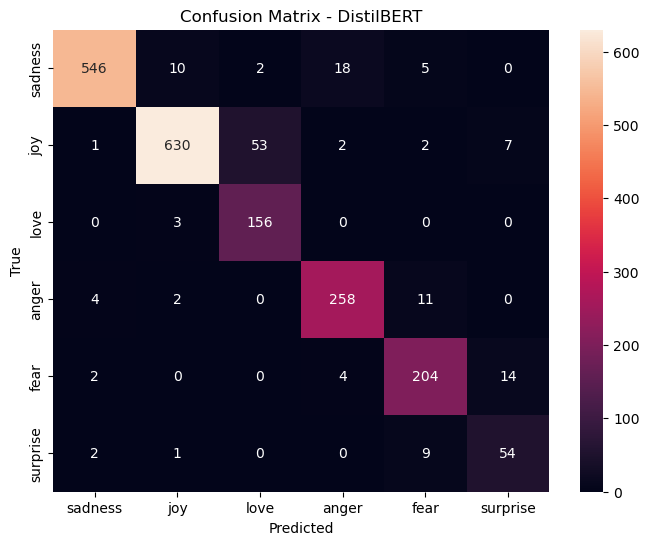

In [20]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            if model_name == 'DistilBERT':
                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            else:
                logits = model(input_ids, attention_mask)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=label_names, output_dict=True)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"{model_name} Test Accuracy: {acc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=label_names))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return acc, report, cm

lstm_acc, lstm_report, lstm_cm = evaluate_model(lstm_model, test_loader, 'LSTM')
gru_acc, gru_report, gru_cm = evaluate_model(gru_model, test_loader, 'GRU')
db_acc, db_report, db_cm = evaluate_model(distilbert_model, test_loader, 'DistilBERT')

     Model  Test Accuracy  Macro F1  Weighted F1
      LSTM         0.8560  0.823117     0.859377
       GRU         0.8965  0.864026     0.898480
DistilBERT         0.9240  0.888860     0.925882


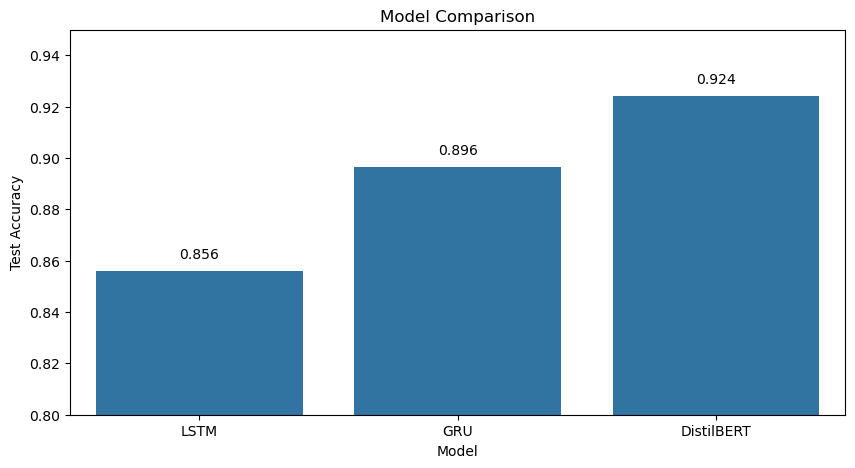

In [21]:
comparison_data = {
    'Model': ['LSTM', 'GRU', 'DistilBERT'],
    'Test Accuracy': [lstm_acc, gru_acc, db_acc],
    'Macro F1': [lstm_report['macro avg']['f1-score'], gru_report['macro avg']['f1-score'], db_report['macro avg']['f1-score']],
    'Weighted F1': [lstm_report['weighted avg']['f1-score'], gru_report['weighted avg']['f1-score'], db_report['weighted avg']['f1-score']]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Test Accuracy', data=comparison_df)
plt.title('Model Comparison')
plt.ylim(0.8, 0.95)

for i, v in enumerate(comparison_df['Test Accuracy']):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.show()

In [22]:
def predict_emotion(text, model, model_type='DistilBERT'):
    model.eval()

    inputs = tokenizer(text, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')

    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        if model_type == 'DistilBERT':
            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        else:
            logits = model(input_ids, attention_mask)

    pred = torch.argmax(logits, dim=1).item()

    return label_names[pred], torch.softmax(logits, dim=1).cpu().numpy()[0]

In [23]:
distilbert_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [24]:
errors = []

for i in range(len(test_texts)):
    if all_labels[i] != all_preds[i]:
        errors.append({
            "text": test_texts[i],
            "actual": label_names[all_labels[i]],
            "predicted": label_names[all_preds[i]]
        })

errors_df = pd.DataFrame(errors)
print("Total errors:", len(errors_df))
errors_df.head(10)

Total errors: 152


,text,actual,predicted
0,i explain why i clung to a relationship with a...,joy,love
1,i am right handed however i play billiards lef...,surprise,fear
2,i feel like i am in paradise kissing those swe...,joy,love
3,when a friend dropped a frog down my neck,anger,fear
4,i actually feel agitated which led to a terrib...,anger,fear
5,im feeling rather angsty and listless,sadness,joy
6,i was so uncomfortable and feeling weird feeli...,surprise,fear
7,i left my garmin on my bike so i was going to ...,joy,surprise
8,i realized what i am passionate about helping ...,joy,love
9,i just feel are ludicrous and wasting space or...,surprise,joy


In [25]:
distilbert_model.save_pretrained("emotion_model")
tokenizer.save_pretrained("emotion_model")

import json

with open("emotion_model/label_names.json", "w") as f:
    json.dump(label_names, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]